# Modelo 2: Árbol de Decisión

En este notebook se entrena un modelo de Árbol de Decisión para clasificar el nivel de cobertura de vacunación por departamento.

La variable objetivo será:

`nivel_cobertura`

Este modelo permite construir reglas de decisión a partir de las variables del dataset, por lo que es más fácil de interpretar que otros modelos más complejos.

In [1]:
# Importar librerías principales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas de evaluación

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Para guardar resultados y modelo

import os
import joblib

# Configuración visual

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [2]:
# Cargar dataset limpio

ruta = "../Datos/datos_limpios_coberturas_vacunacion.csv"

df = pd.read_csv(ruta)

df.head()

,cod_departamento,departamento,anio,biologico,cobertura_vacunacion,estado_indicador,rango_bajo_inicio,rango_bajo_fin,rango_medio_inicio,rango_medio_fin,rango_adecuado_inicio,rango_adecuado_fin,cobertura_original,cobertura_porcentaje,nivel_cobertura
0,5,Antioquia,2019,BCG - Antituberculosa Recién Nacido,0.9389,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99,0.9389,93.89,Adecuada
1,8,Atlántico,2019,BCG - Antituberculosa Recién Nacido,1.0379,IndicatorState3,0,49.99,80,89.99,90,94.99,10379.0000,103.79,Alta
2,11,Bogotá D.C.,2019,BCG - Antituberculosa Recién Nacido,1.0105,IndicatorState3,0,49.99,80,89.99,90,94.99,10105.0000,101.05,Alta
3,13,Bolívar,2019,BCG - Antituberculosa Recién Nacido,0.7170,IndicatorState1,0,49.99,80,89.99,90,94.99,0.7170,71.70,Baja
4,15,Boyacá,2019,BCG - Antituberculosa Recién Nacido,0.9409,ThreeSymbolUnCircledCheck,0,49.99,80,89.99,90,94.99,0.9409,94.09,Adecuada


In [3]:
# Tamaño del dataset

print("Filas y columnas:", df.shape)

Filas y columnas: (660, 15)


In [4]:
# Información general

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cod_departamento       660 non-null    int64  
 1   departamento           660 non-null    str    
 2   anio                   660 non-null    int64  
 3   biologico              660 non-null    str    
 4   cobertura_vacunacion   660 non-null    float64
 5   estado_indicador       660 non-null    str    
 6   rango_bajo_inicio      660 non-null    int64  
 7   rango_bajo_fin         660 non-null    float64
 8   rango_medio_inicio     660 non-null    int64  
 9   rango_medio_fin        660 non-null    float64
 10  rango_adecuado_inicio  660 non-null    int64  
 11  rango_adecuado_fin     660 non-null    float64
 12  cobertura_original     660 non-null    float64
 13  cobertura_porcentaje   660 non-null    float64
 14  nivel_cobertura        660 non-null    str    
dtypes: float64(6), in

In [5]:
# Revisar columnas

df.columns

Index(['cod_departamento', 'departamento', 'anio', 'biologico',
       'cobertura_vacunacion', 'estado_indicador', 'rango_bajo_inicio',
       'rango_bajo_fin', 'rango_medio_inicio', 'rango_medio_fin',
       'rango_adecuado_inicio', 'rango_adecuado_fin', 'cobertura_original',
       'cobertura_porcentaje', 'nivel_cobertura'],
      dtype='str')

In [6]:
# Distribución de la variable objetivo

df["nivel_cobertura"].value_counts()

nivel_cobertura
Media       189
Muy baja    140
Baja        128
Adecuada    104
Alta         99
Name: count, dtype: int64

In [7]:
# Distribución porcentual

df["nivel_cobertura"].value_counts(normalize=True).map("{:.2%}".format)

nivel_cobertura
Media       28.64%
Muy baja    21.21%
Baja        19.39%
Adecuada    15.76%
Alta        15.00%
Name: proportion, dtype: str

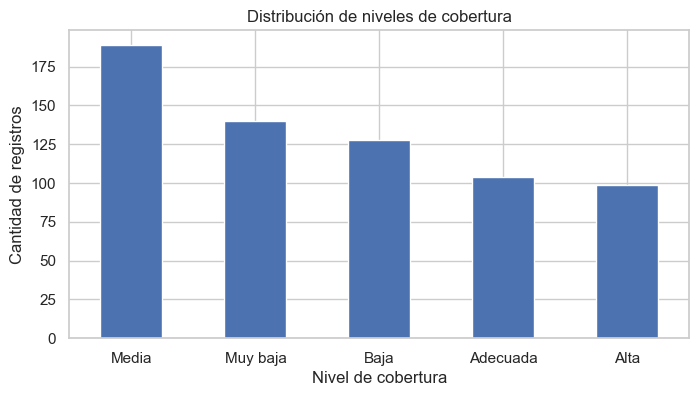

In [8]:
# Gráfico de distribución

plt.figure(figsize=(8, 4))

df["nivel_cobertura"].value_counts().plot(kind="bar")

plt.title("Distribución de niveles de cobertura")
plt.xlabel("Nivel de cobertura")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)

plt.show()

## Selección de variables

Para este modelo se utilizarán variables relacionadas con el departamento, el año y el biológico.

No se usarán directamente las columnas de cobertura, porque la variable objetivo `nivel_cobertura` fue creada a partir de la cobertura en porcentaje.

Esto evita que el modelo aprenda la respuesta de forma directa.

In [9]:
# Variable objetivo

y = df["nivel_cobertura"]

# Variables predictoras

X = df[[
    "cod_departamento",
    "departamento",
    "anio",
    "biologico"
]]

X.head()

,cod_departamento,departamento,anio,biologico
0,5,Antioquia,2019,BCG - Antituberculosa Recién Nacido
1,8,Atlántico,2019,BCG - Antituberculosa Recién Nacido
2,11,Bogotá D.C.,2019,BCG - Antituberculosa Recién Nacido
3,13,Bolívar,2019,BCG - Antituberculosa Recién Nacido
4,15,Boyacá,2019,BCG - Antituberculosa Recién Nacido


In [10]:
# Variables numéricas y categóricas

variables_numericas = ["cod_departamento", "anio"]
variables_categoricas = ["departamento", "biologico"]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['cod_departamento', 'anio']
Variables categóricas: ['departamento', 'biologico']


In [11]:
# Dividir datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (495, 4)
Tamaño X_test: (165, 4)
Tamaño y_train: (495,)
Tamaño y_test: (165,)


In [12]:
# Preprocesamiento

preprocesamiento = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), variables_categoricas)
    ],
    remainder="passthrough"
)

# Crear modelo de Árbol de Decisión

modelo_arbol = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

# Crear pipeline

pipeline_arbol = Pipeline(
    steps=[
        ("preprocesamiento", preprocesamiento),
        ("modelo", modelo_arbol)
    ]
)

pipeline_arbol

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [13]:
# Entrenar modelo

pipeline_arbol.fit(X_train, y_train)

print("Modelo de Árbol de Decisión entrenado correctamente.")

Modelo de Árbol de Decisión entrenado correctamente.


In [14]:
# Realizar predicciones

y_pred = pipeline_arbol.predict(X_test)

y_pred[:10]

array(['Baja', 'Adecuada', 'Alta', 'Baja', 'Muy baja', 'Media',
       'Muy baja', 'Alta', 'Adecuada', 'Adecuada'], dtype=object)

In [15]:
# Calcular métricas principales

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=== MÉTRICAS ÁRBOL DE DECISIÓN ===")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

=== MÉTRICAS ÁRBOL DE DECISIÓN ===
Accuracy: 0.5576
Precision: 0.6946
Recall: 0.5576
F1 Score: 0.5363


In [16]:
# Reporte detallado por clase

print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, zero_division=0))

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

    Adecuada       0.28      0.65      0.39        26
        Alta       0.55      0.64      0.59        25
        Baja       0.57      0.62      0.60        32
       Media       0.86      0.13      0.22        47
    Muy baja       1.00      0.94      0.97        35

    accuracy                           0.56       165
   macro avg       0.65      0.60      0.55       165
weighted avg       0.69      0.56      0.54       165



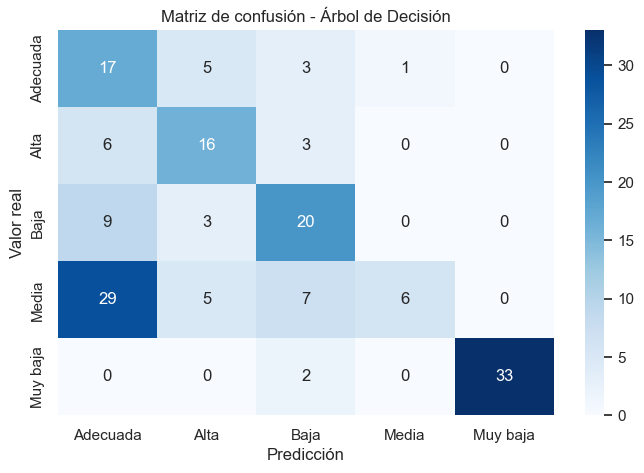

In [17]:
# Matriz de confusión

matriz = confusion_matrix(y_test, y_pred, labels=pipeline_arbol.classes_)

plt.figure(figsize=(8, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=pipeline_arbol.classes_,
    yticklabels=pipeline_arbol.classes_
)

plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

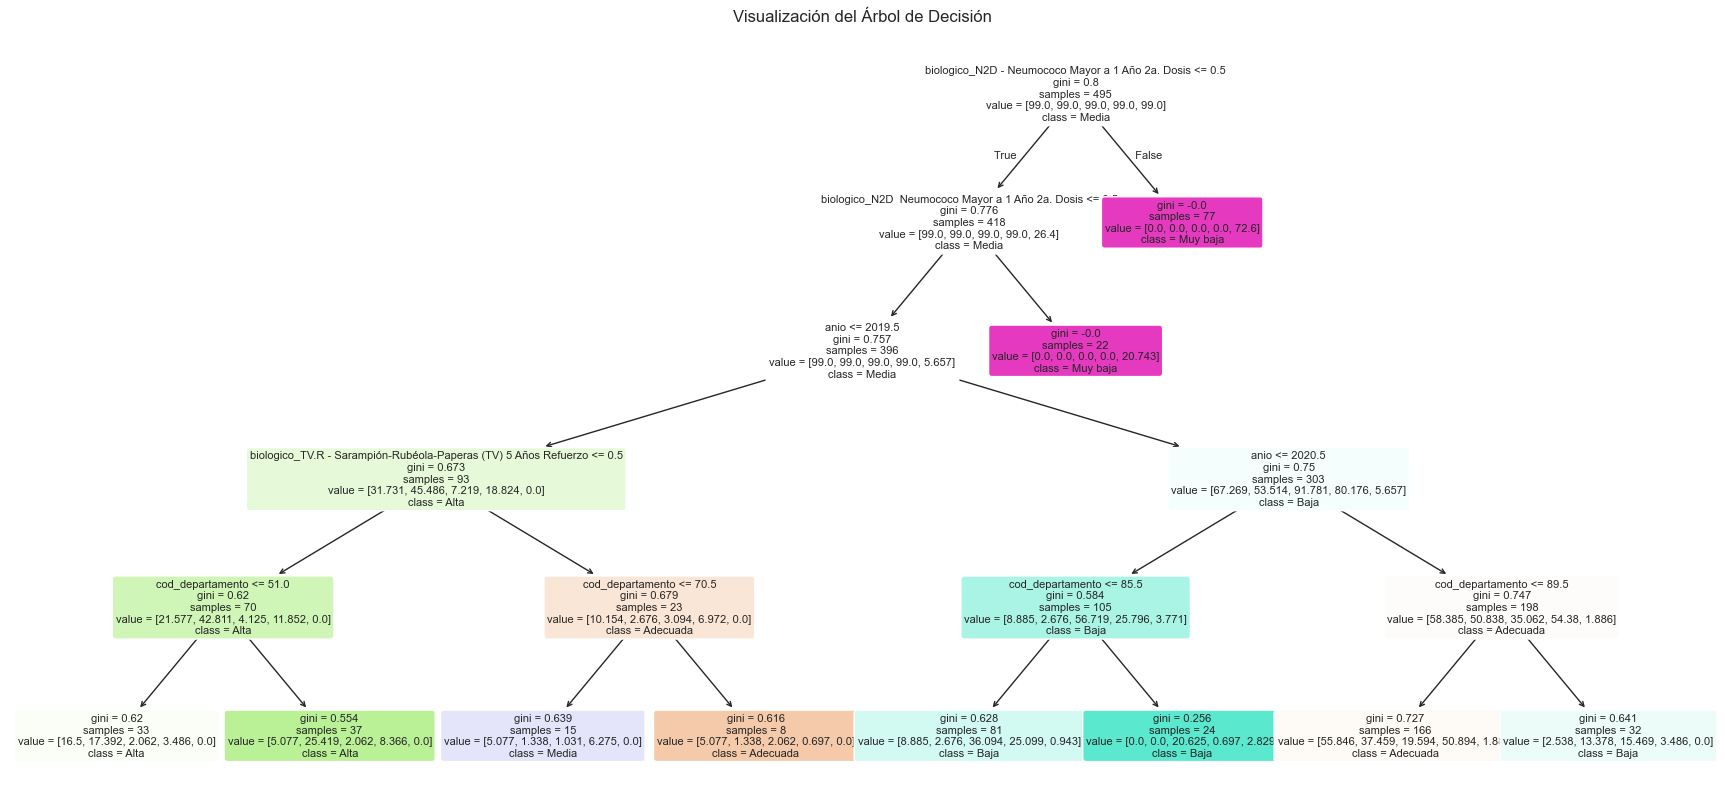

In [18]:
# Obtener nombres de variables después del preprocesamiento

preprocesador_entrenado = pipeline_arbol.named_steps["preprocesamiento"]

nombres_cat = preprocesador_entrenado.named_transformers_["cat"].get_feature_names_out(variables_categoricas)

nombres_variables = list(nombres_cat) + variables_numericas

# Obtener modelo entrenado

arbol_entrenado = pipeline_arbol.named_steps["modelo"]

plt.figure(figsize=(22, 10))

plot_tree(
    arbol_entrenado,
    feature_names=nombres_variables,
    class_names=arbol_entrenado.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Visualización del Árbol de Decisión")
plt.show()

In [19]:
# Importancia de variables

importancias = arbol_entrenado.feature_importances_

tabla_importancias = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

tabla_importancias.head(15)

,variable,importancia
37,biologico_N2D - Neumococo Mayor a 1 Año 2a. Dosis,0.488935
43,anio,0.197692
36,biologico_N2D Neumococo Mayor a 1 Año 2a. Dosis,0.172160
42,cod_departamento,0.111102
41,biologico_TV.R - Sarampión-Rubéola-Paperas (TV...,0.030110
4,departamento_Archipiélago de San Andrés Provid...,0.000000
6,departamento_Bogotá D.C.,0.000000
5,departamento_Atlántico,0.000000
0,departamento_Amazonas,0.000000
1,departamento_Antioquia,0.000000


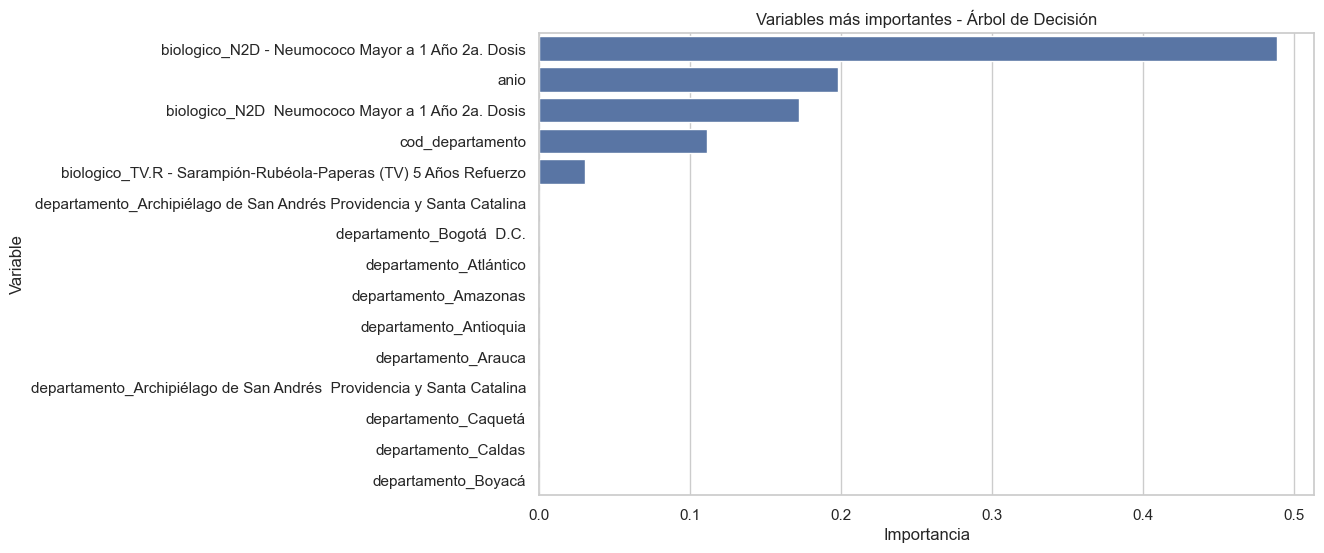

In [20]:
# Gráfico de las variables más importantes

top_importancias = tabla_importancias.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_importancias,
    x="importancia",
    y="variable"
)

plt.title("Variables más importantes - Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

In [21]:
# Crear carpeta de resultados si no existe

os.makedirs("../Resultados", exist_ok=True)

# Guardar métricas en dataframe

resultados_arbol = pd.DataFrame({
    "modelo": ["Árbol de Decisión"],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1_score": [f1]
})

resultados_arbol

,modelo,accuracy,precision,recall,f1_score
0,Árbol de Decisión,0.557576,0.694609,0.557576,0.536335


In [22]:
# Guardar resultados en CSV

resultados_arbol.to_csv(
    "../Resultados/metricas_arbol_decision.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Métricas guardadas correctamente.")

Métricas guardadas correctamente.


In [23]:
# Crear carpeta para modelos entrenados

os.makedirs("../Modelos_entrenados", exist_ok=True)

# Guardar modelo

joblib.dump(
    pipeline_arbol,
    "../Modelos_entrenados/modelo_arbol_decision.pkl"
)

print("Modelo de Árbol de Decisión guardado correctamente.")

Modelo de Árbol de Decisión guardado correctamente.


## Interpretación del modelo

El Árbol de Decisión permite clasificar los niveles de cobertura de vacunación mediante reglas construidas a partir de las variables del dataset.

A diferencia de la Regresión Logística, este modelo puede capturar relaciones no lineales entre las variables.

Además, permite visualizar la estructura de decisión y analizar cuáles variables tienen mayor importancia en la clasificación.